In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numpy pandas scikit-learn matplotlib seaborn tensorflow

In [3]:
import numpy as np
import pandas as pd
import zipfile
import os
import sys
import random
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [4]:
local_zip = '/content/drive/MyDrive/data_folder.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data_folder')
zip_ref.close()

base_dir = '/content/data_folder'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [5]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0,width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
validation_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen=ImageDataGenerator(rescale=1.0/255.0)

In [6]:
train_generator = train_datagen.flow_from_directory(train_dir, batch_size = 64, class_mode = 'binary', target_size = (200, 200))
validation_generator = validation_datagen.flow_from_directory(validation_dir,  batch_size = 64, class_mode = 'binary', target_size = (200, 200), shuffle = False)
test_generator=test_datagen.flow_from_directory(test_dir,  batch_size = 64, class_mode = 'binary', target_size = (200, 200), shuffle = False)

Found 20000 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [ ]:
def define_model():
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(200, 200, 3)))
 model.add(MaxPooling2D((2, 2)))
 model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
 model.add(MaxPooling2D((2, 2)))
 model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
 model.add(MaxPooling2D((2, 2)))
 model.add(Flatten())
 model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
 model.add(Dense(1, activation='sigmoid'))
 opt = SGD(learning_rate=0.01, momentum=0.9)
 model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
 return model

In [ ]:
model=define_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,240,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,333,505 (39.42 MB)

 Trainable params: 10,333,505 (39.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es=EarlyStopping(monitor='val_accuracy',patience=8,start_from_epoch=30,restore_best_weights=True)
cp = ModelCheckpoint('/content/drive/MyDrive/best_cnn_model_50epoch.h5', monitor='val_accuracy', save_best_only=True, mode='max',verbose=0)

In [ ]:
cnn_his=model.fit(train_generator,epochs=50, steps_per_epoch=len(train_generator),validation_data=validation_generator, validation_steps=len(validation_generator),callbacks=[cp,es])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.5343 - loss: 0.9331

313/313 ━━━━━━━━━━━━━━━━━━━━ 226s 697ms/step - accuracy: 0.5345 - loss: 0.9324 - val_accuracy: 0.6704 - val_loss: 0.6146
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.6652 - loss: 0.6060

313/313 ━━━━━━━━━━━━━━━━━━━━ 241s 654ms/step - accuracy: 0.6652 - loss: 0.6059 - val_accuracy: 0.7244 - val_loss: 0.5401
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.7172 - loss: 0.5512

313/313 ━━━━━━━━━━━━━━━━━━━━ 263s 656ms/step - accuracy: 0.7173 - loss: 0.5511 - val_accuracy: 0.7280 - val_loss: 0.5410
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7509 - loss: 0.5127

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 640ms/step - accuracy: 0.9299 - loss: 0.1727 - val_accuracy: 0.9108 - val_loss: 0.2396
Epoch 41/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 660ms/step - accuracy: 0.9345 - loss: 0.1603 - val_accuracy: 0.9076 - val_loss: 0.2686
Epoch 42/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 260s 655ms/step - accuracy: 0.9329 - loss: 0.1633 - val_accuracy: 0.9076 - val_loss: 0.2409
Epoch 43/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 651ms/step - accuracy: 0.9348 - loss: 0.1611 - val_accuracy: 0.9020 - val_loss: 0.2591
Epoch 44/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 647ms/step - accuracy: 0.9368 - loss: 0.1579 - val_accuracy: 0.9044 - val_loss: 0.2512
Epoch 45/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9350 - loss: 0.1599

313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 653ms/step - accuracy: 0.9350 - loss: 0.1599 - val_accuracy: 0.9144 - val_loss: 0.2305
Epoch 46/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9411 - loss: 0.1480

313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 649ms/step - accuracy: 0.9411 - loss: 0.1480 - val_accuracy: 0.9164 - val_loss: 0.2267
Epoch 47/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9420 - loss: 0.1455

313/313 ━━━━━━━━━━━━━━━━━━━━ 205s 654ms/step - accuracy: 0.9420 - loss: 0.1455 - val_accuracy: 0.9168 - val_loss: 0.2435
Epoch 48/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 650ms/step - accuracy: 0.9372 - loss: 0.1499 - val_accuracy: 0.9092 - val_loss: 0.2359
Epoch 49/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9504 - loss: 0.1299

313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 645ms/step - accuracy: 0.9504 - loss: 0.1299 - val_accuracy: 0.9192 - val_loss: 0.2119
Epoch 50/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 663ms/step - accuracy: 0.9465 - loss: 0.1355 - val_accuracy: 0.9000 - val_loss: 0.2964


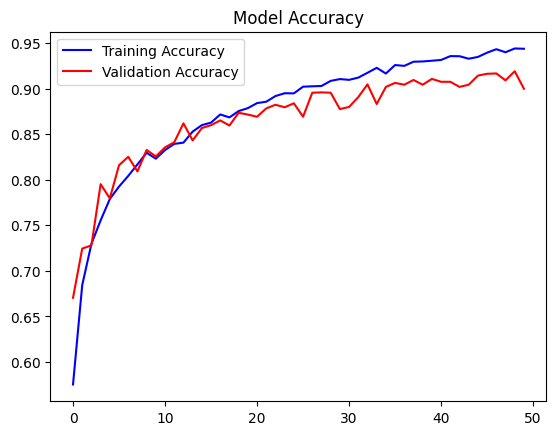

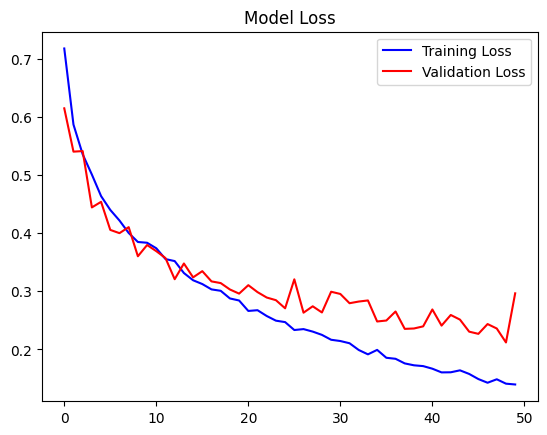

In [ ]:
acc=cnn_his.history['accuracy']
val_acc=cnn_his.history['val_accuracy']
epochs=range(len(acc))
plt.plot(epochs,acc,'b',label='Training Accuracy')
plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.figure()

loss=cnn_his.history['loss']
val_loss=cnn_his.history['val_loss']
plt.plot(epochs,loss,'b',label='Training Loss')
plt.plot(epochs,val_loss,'r',label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()


In [ ]:
saved_model = load_model('/content/drive/MyDrive/best_cnn_model_50epoch.h5')

In [7]:
saved_model = load_model('/content/drive/MyDrive/best_cnn_model_50epoch.h5')
saved_model.evaluate(validation_generator)
saved_model.evaluate(train_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9214 - loss: 0.1964
313/313 ━━━━━━━━━━━━━━━━━━━━ 194s 619ms/step - accuracy: 0.9475 - loss: 0.1395


[0.13938748836517334, 0.9449999928474426]

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step


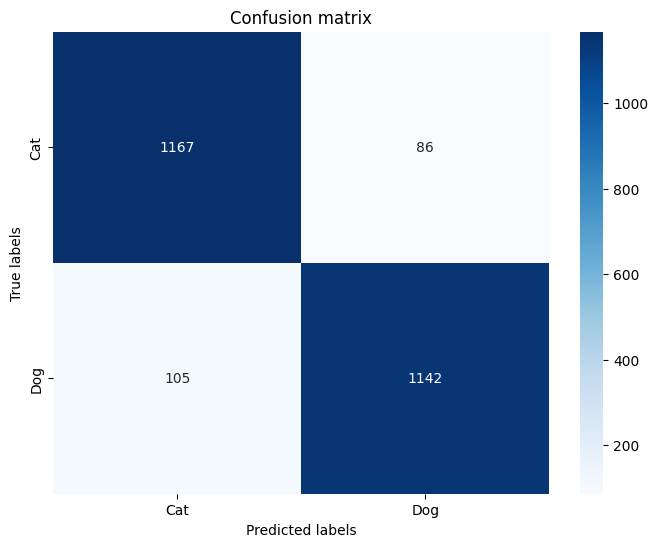

In [8]:
predictions = saved_model.predict(test_generator).flatten()
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion matrix')
plt.show()


In [9]:
predictions = saved_model.predict(test_generator).flatten()
y_pred = (predictions > 0.5).astype(int)

print('Classification report CNN model:')
print(classification_report(test_generator.classes, y_pred, target_names=['Cat', 'Dog']))


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
Classification report CNN model:
              precision    recall  f1-score   support

         Cat       0.92      0.93      0.92      1253
         Dog       0.93      0.92      0.92      1247

    accuracy                           0.92      2500
   macro avg       0.92      0.92      0.92      2500
weighted avg       0.92      0.92      0.92      2500

